In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [9]:
df = pd.read_csv(r"C:\Users\SHREYA\Downloads\archive (10)\energydata_complete.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (19735, 30)


,index,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [11]:
df['date'] = pd.to_datetime(df['date'])

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month

df.head()

,index,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day,month
0,0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,...,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,Monday,1
1,1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,...,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,Monday,1
2,2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,...,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,Monday,1
3,3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,...,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,Monday,1
4,4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,...,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,Monday,1


In [13]:
def usage_category(value):

    if value < 50:
        return "Low"
    
    elif value < 100:
        return "Medium"
    
    else:
        return "High"

df["usage_level"] = df["Appliances"].apply(usage_category)

y = df["usage_level"]

In [17]:
X = df[["hour","lights","T_out","RH_out"]]

y = df["usage_level"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [23]:
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5039270331897644


In [29]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report\n")

print(classification_report(y_test, predictions))

Accuracy: 0.5039270331897644

Classification Report

              precision    recall  f1-score   support

        High       0.51      0.44      0.47      1036
         Low       0.27      0.37      0.32       619
      Medium       0.59      0.57      0.58      2292

    accuracy                           0.50      3947
   macro avg       0.46      0.46      0.46      3947
weighted avg       0.52      0.50      0.51      3947



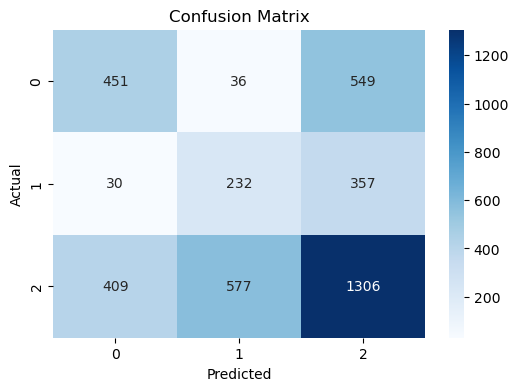

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

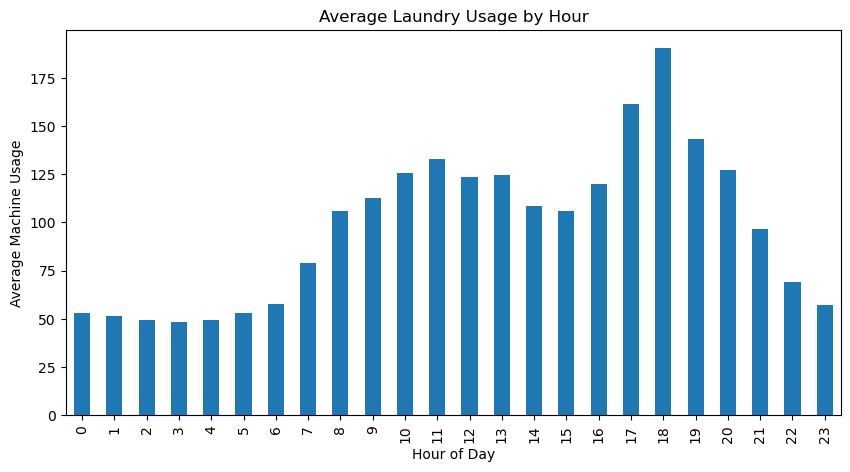

In [35]:
hour_usage = df.groupby("hour")["Appliances"].mean()

plt.figure(figsize=(10,5))

hour_usage.plot(kind='bar')

plt.title("Average Laundry Usage by Hour")

plt.xlabel("Hour of Day")

plt.ylabel("Average Machine Usage")

plt.show()

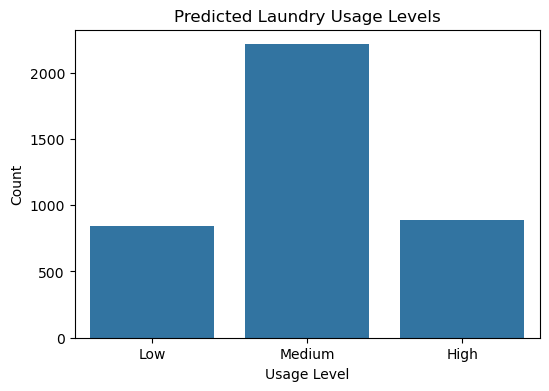

In [37]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=predictions)

plt.title("Predicted Laundry Usage Levels")

plt.xlabel("Usage Level")

plt.ylabel("Count")

plt.show()

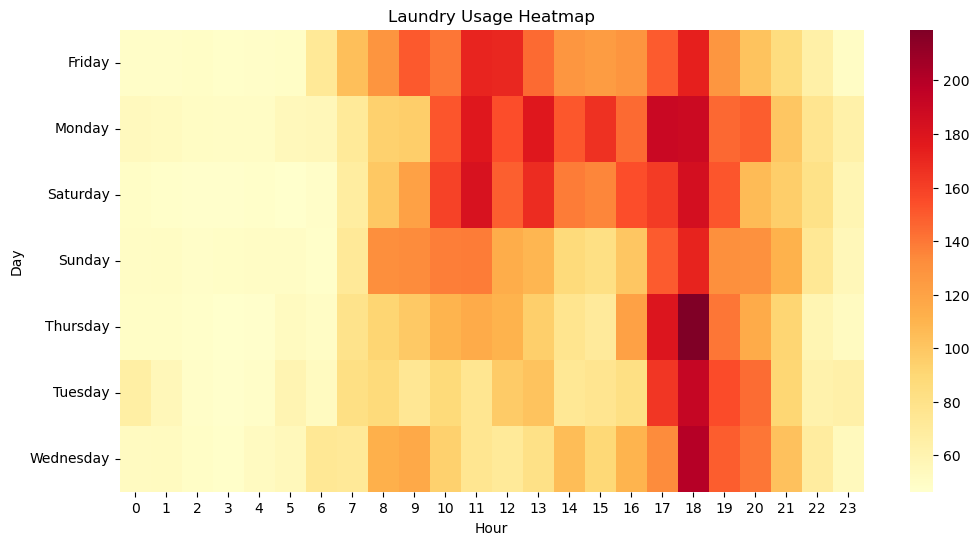

In [39]:
pivot_table = df.pivot_table(values="Appliances", index="day", columns="hour", aggfunc="mean")

plt.figure(figsize=(12,6))

sns.heatmap(pivot_table, cmap="YlOrRd")

plt.title("Laundry Usage Heatmap")

plt.xlabel("Hour")

plt.ylabel("Day")

plt.show()